In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#Carga de datos saltando la fila de título del informe
# Usamos skiprows=1 porque los CSVs tienen una fila vacía/título arriba
df_ventas = pd.read_csv('../data/informe_ventas.csv', skiprows=1)
df_reservas = pd.read_csv('../data/informe_reservas.csv', skiprows=1)

#Función de limpieza
def limpiar_nombres_columnas(df):
    df.columns = (df.columns
                  .str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace('¿', '')
                  .str.replace('?', '')
                  .str.replace('.', '')
                  .str.replace('á', 'a')
                  .str.replace('é', 'e')
                  .str.replace('í', 'i')
                  .str.replace('ó', 'o')
                  .str.replace('ú', 'u'))
    return df

df_ventas = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

#Verificación rápida
print("Columnas en Ventas:", df_ventas.columns.tolist())
print("Columnas en Reservas:", df_reservas.columns.tolist())

Columnas en Ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'codigo_postal_de_tarjeta_de_credito', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'email']
Columnas en Reservas: ['mes_de_la_disponibilidad', 'producto', 'id_de_reserva', 'reprogramacion', 'email', 'nº_de_pax', 'cargos_de_gestion', 'total_pagado_tras_cargos_de_procesamiento']


In [3]:
#Identificar columnas monetarias dinámicamente si el nombre falla
col_dinero_ventas = 'neto'
# Buscamos una columna que contenga 'total' o 'pagado' en reservas
col_dinero_reservas = [c for c in df_reservas.columns if 'total' in c or 'pagado' in c][0]

def limpiar_moneda(valor):
    if isinstance(valor, str):
        # Quitamos €, espacios y manejamos el formato europeo (1.200,50 -> 1200.50)
        valor = valor.replace('€', '').replace('.', '').replace(',', '.').strip()
    return pd.to_numeric(valor, errors='coerce')

#Limpieza
df_ventas[col_dinero_ventas] = df_ventas[col_dinero_ventas].apply(limpiar_moneda)
df_reservas['total_a_recibir'] = df_reservas[col_dinero_reservas].apply(limpiar_moneda)

#Unificación de Fechas 
#Buscamos la columna de fecha en ventas
col_fecha_ventas = [c for c in df_ventas.columns if 'creado' in c or 'fecha' in c][0]
df_ventas['fecha_hora_creacion_venta'] = pd.to_datetime(df_ventas[col_fecha_ventas], dayfirst=True, errors='coerce')

#Conversión de Reprogramados
#Buscamos la columna de reprogramación
col_repro = [c for c in df_ventas.columns if 'repro' in c][0]
mapeo_bool = {'Sí': 1, 'No': 0, 'S': 1, 'N': 0, 'Si': 1, 'Yes': 1, 'No': 0}
df_ventas['reprogramado'] = df_ventas[col_repro].map(mapeo_bool).fillna(0).astype(int)

print("✅ Limpieza completada con éxito.")
print(f"Columnas detectadas: Dinero({col_dinero_reservas}), Fecha({col_fecha_ventas})")

C:\Users\pc\AppData\Local\Temp\ipykernel_31572\1253934061.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ventas['fecha_hora_creacion_venta'] = pd.to_datetime(df_ventas[col_fecha_ventas], dayfirst=True, errors='coerce')


✅ Limpieza completada con éxito.
Columnas detectadas: Dinero(total_pagado_tras_cargos_de_procesamiento), Fecha(creado_el)


In [4]:
#ANONIMIZACIÓN
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
import sys
sys.path.insert(0, '../utils')
from funciones import anonimizar

df_ventas, df_reservas = anonimizar(df_ventas, df_reservas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'fecha_hora_creacion_venta', 'reprogramado', 'cliente_id', 'cp_area']


In [5]:
#Unimos por cliente_id para ver el comportamiento histórico del cliente
df_master = pd.merge(df_ventas, df_reservas, on='cliente_id', how='inner', suffixes=('_venta', '_reserva'))

#Creamos una columna para identificar si es un cliente recurrente
asiduidad_clientes = df_master.groupby('cliente_id').size().reset_index(name='num_compras')
df_master = pd.merge(df_master, asiduidad_clientes, on='cliente_id')

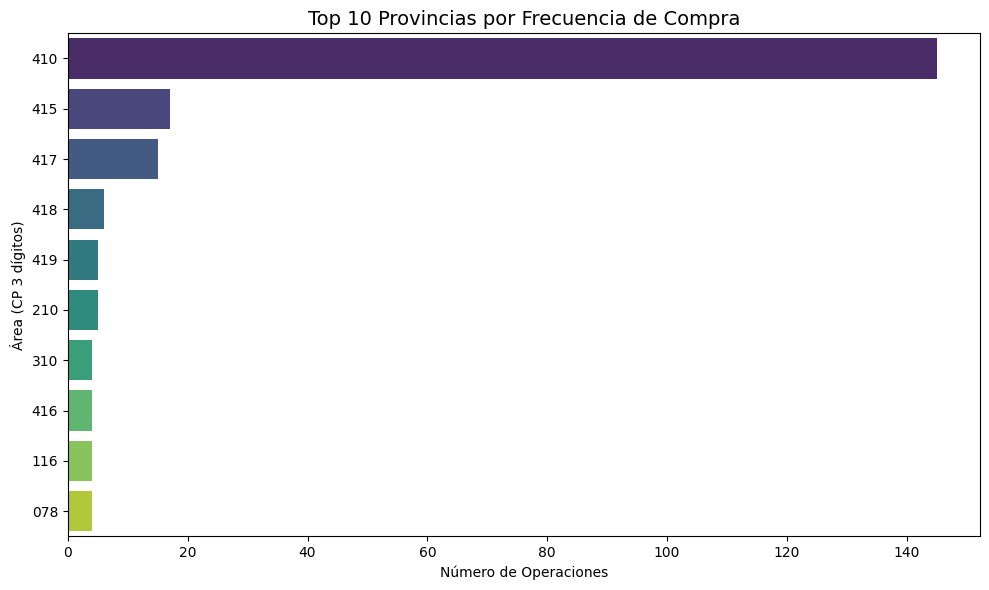

In [6]:
# GRÁFICA 1 — Top 10 provincias por frecuencia de compra (clientes recurrentes)
top_geografico = df_master[df_master['num_compras'] > 1]['cp_area'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_geografico.values,
    y=top_geografico.index,
    palette='viridis',
    hue=top_geografico.index,
    legend=False
)
plt.title('Top 10 Provincias por Frecuencia de Compra', fontsize=14)
plt.xlabel('Número de Operaciones')
plt.ylabel('Área (CP 3 dígitos)')
plt.tight_layout()
plt.savefig('../img/distribucion_geografica.png')
plt.show()

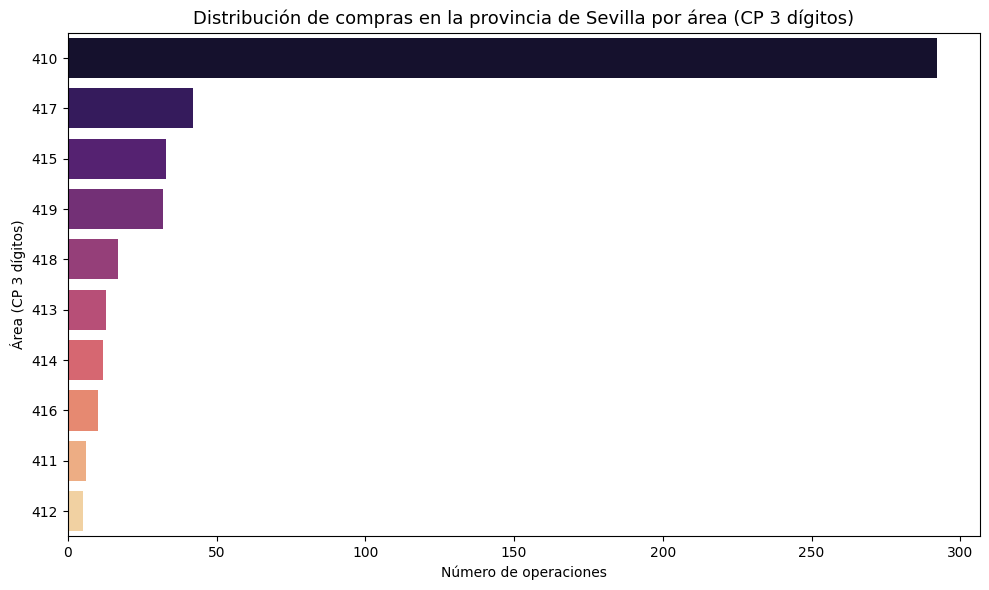

In [7]:
# GRÁFICA 2 — Desglose de Sevilla por área (CP 3 dígitos, todas las transacciones)
sevilla = df_master[df_master['cp_area'].str.startswith('41', na=False)]
top_sevilla = sevilla['cp_area'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_sevilla.values,
    y=top_sevilla.index,
    palette='magma',
    hue=top_sevilla.index,
    legend=False
)
plt.title('Distribución de compras en la provincia de Sevilla por área (CP 3 dígitos)', fontsize=13)
plt.xlabel('Número de operaciones')
plt.ylabel('Área (CP 3 dígitos)')
plt.tight_layout()
plt.savefig('../img/distribucion_sevilla.png')
plt.show()

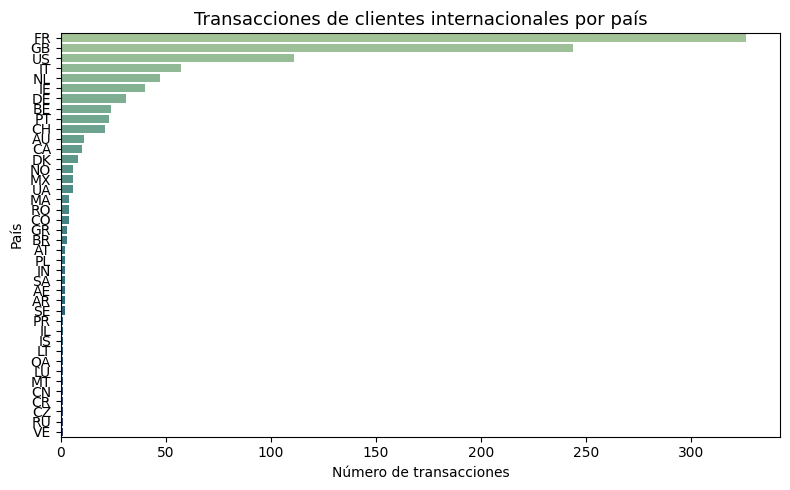

In [8]:
# GRÁFICA 3 — Clientes internacionales por país (pais_del_telefono)
# Se usa df_ventas directamente para no perder internacionales sin reserva
internacionales = (
    df_ventas[df_ventas['pais_del_telefono'].notna() &
              (df_ventas['pais_del_telefono'] != 'ES')]
    ['pais_del_telefono'].value_counts()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=internacionales.values,
    y=internacionales.index,
    palette='crest',
    hue=internacionales.index,
    legend=False
)
plt.title('Transacciones de clientes internacionales por país', fontsize=13)
plt.xlabel('Número de transacciones')
plt.ylabel('País')
plt.tight_layout()
plt.savefig('../img/distribucion_internacional.png')
plt.show()